# bayesflow_hpo Quickstart

A minimal end-to-end example that shows how to run **hyperparameter optimization** (HPO) for a [BayesFlow 2.x](https://bayesflow.org) amortized inference workflow.

We will:

1. Define a simple Gaussian **simulator** (prior + likelihood).
2. Build a BayesFlow **adapter** that maps raw simulation output to the format expected by the neural network.
3. Generate a fixed **validation dataset** for simulation-based calibration (SBC) diagnostics.
4. Launch an Optuna-backed **multi-objective optimization** run that searches over network architectures and training hyperparameters.

## 0. Setup

Install the package (editable mode from the repo root) and import the two libraries we need:
- **`bayesflow`** — the core amortized Bayesian inference framework (simulators, adapters, workflows),
- **`bayesflow_hpo`** — this package, which adds HPO search spaces, objectives, and validation utilities on top.

In [1]:
%pip install --quiet --upgrade -e ..

import bayesflow as bf
import bayesflow_hpo as hpo
import numpy as np

Note: you may need to restart the kernel to use updated packages.


INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
c:\Users\Matze\Documents\GitHub\bayesflow_projects\bayesflow_hpo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Simulator, Adapter & Validation Data

**Simulator** — We define a toy generative model with a 1-D Gaussian prior $\theta \sim \mathcal{N}(0, 1)$ and a Gaussian likelihood $x_i \mid \theta \sim \mathcal{N}(\theta, 1)$ producing 12 observations per dataset. This is deliberately simple so the notebook runs in seconds.

**Adapter** — The `bf.Adapter` tells BayesFlow how to reshape the raw simulation dictionaries into the tensor format the neural network expects:
- `.as_set(["x"])` marks observation vectors as exchangeable (order doesn't matter),
- `.rename("theta", "inference_variables")` maps the parameter to the inference target,
- `.concatenate(["x"], into="summary_variables")` stacks observations into the summary input.

**Validation data** — `hpo.generate_validation_dataset` draws a fixed batch of (parameter, data) pairs from the simulator. This dataset is reused across *every* HPO trial so that metric comparisons are fair (no noise from resampling).

In [2]:
def prior_fn():
    return {"theta": np.random.normal(0.0, 1.0, size=(1,)).astype("float32")}


def likelihood_fn(theta):
    theta_value = float(np.squeeze(theta))
    x = np.random.normal(theta_value, 1.0, size=(12, 1)).astype("float32")
    return {"x": x}


simulator = bf.simulators.make_simulator([prior_fn, likelihood_fn])
adapter = (
    bf.Adapter()
    .as_set(["x"])
    .rename("theta", "inference_variables")
    .concatenate(["x"], into="summary_variables", axis=-1)
)

validation_data = hpo.generate_validation_dataset(
    simulator=simulator,
    param_keys=["theta"],
    data_keys=["x"],
    sims_per_condition=100,
)

## 2. Run HPO

`hpo.optimize` is the main entry point. Under the hood it:

1. **Creates an Optuna study** with two objectives: *mean(calibration_error + nrmse)* (minimize) and *model size* (minimize) — a Pareto-style trade-off between accuracy and complexity.
2. **Samples hyperparameters** from a `CompositeSearchSpace` that covers the inference network (coupling flow), the summary network (DeepSet), and training settings (learning rate).
3. **Builds, trains, and validates** a fresh `bf.BasicWorkflow` for each trial, using SBC-based metrics on the fixed validation dataset.
4. **Reports results** back to Optuna, which guides future sampling via its TPE (Tree-structured Parzen Estimator) sampler.

Key arguments in this example:
| Argument | Value | Why |
|---|---|---|
| `n_trials` | 10 | Number of HPO configurations to try (increase for real use) |
| `epochs` | 30 | Enough gradient steps for meaningful metric signal |
| `batches_per_epoch` | 30 | 900 gradient steps per trial — fast demo |
| `max_param_count` | 500,000 | Reject very large models before training |
| `objective_metrics` | `["calibration_error", "nrmse"]` | Combines coverage quality with point-estimate accuracy |
| `objective_mode` | `"mean"` | Average both metrics into one scalar objective |
| `inference_conditions` | `["num_obs"]` | Tell the inference network to condition on sample size |

After optimization, `study.best_trials` returns the Pareto-optimal trial(s).

In [3]:
import bayesflow_hpo as hpo

# Use a focused search space for the demo (coupling flow + deep set).
# The default also includes flow matching + set transformer, which are
# slower to converge on this toy problem.
search_space = hpo.CompositeSearchSpace(
    inference_space=hpo.FlowMatchingSpace(),
    summary_space=hpo.DeepSetSpace(),
    training_space=hpo.TrainingSpace(),
)

study = hpo.optimize(
    # model-specific arguments
    simulator=simulator,
    adapter=adapter,
    param_keys=["theta"],
    data_keys=["x", "num_obs"],
    validation_data=validation_data,
    inference_conditions=["num_obs"],
    # optimization-specific arguments
    search_space=search_space,    
    n_trials=10,
    epochs=30,
    batches_per_epoch=30,
    max_param_count=500_000,
    objective_metrics=["calibration_error", "nrmse"],
    objective_mode="pareto",
    show_progress_bar=False,
)

print(f"Trials: {len(study.trials)}")
print(f"Pareto-optimal trials: {len(study.best_trials)}")
if study.best_trials:
    best = min(
        study.best_trials,
        key=lambda t: t.user_attrs.get("calibration_error", float("inf")),
    )
    print(
        f"Best trial by calibration_error: "
        f"{best.user_attrs.get('calibration_error', float('nan')):.4f} "
        f"(nrmse={best.user_attrs.get('nrmse', float('nan')):.4f}, "
        f"params={best.user_attrs.get('param_count', '?')})"
    )
else:
    print("No completed trials satisfied the budget.")

c:\Users\Matze\Documents\GitHub\bayesflow_projects\bayesflow_hpo\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\Matze\Documents\GitHub\bayesflow_projects\bayesflow_hpo\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``constraints_func`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-03-11 20:25:27,507] A new study created in RDB with name: bayesflow_hpo
INFO:bayesflow:Fitting on dataset instance of OnlineDataset.


Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - loss: 1.8635 - moving_avg_loss: 1.8635
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - loss: 1.1756 - moving_avg_loss: 1.5196
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - loss: 0.9735 - moving_avg_loss: 1.3375
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 138ms/step - loss: 0.8132 - moving_avg_loss: 1.2064
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - loss: 0.7651 - moving_avg_loss: 1.1182
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - loss: 0.7300 - moving_avg_loss: 1.0535
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 138ms/step - loss: 0.6908 - moving_avg_loss: 1.0017
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - loss: 0.7023 - moving_avg_loss: 0.8358
Epoch 9/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 138ms/step - loss: 0.6207 - moving_avg_loss: 0.7565
Epoch 10/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 138ms/step - loss: 0.6451 - moving_avg_loss: 0.7096
Epoch 11/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 0.6196

Sampling: 100%|██████████| 1/1 [00:52<00:00, 52.96s/batch]


30/30 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - loss: 0.6196 - moving_avg_loss: 0.6819
Epoch 12/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - loss: 0.6485 - moving_avg_loss: 0.6653
Epoch 13/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - loss: 0.5798 - moving_avg_loss: 0.6438
Epoch 14/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - loss: 0.5774 - moving_avg_loss: 0.6276
Epoch 15/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - loss: 0.5929 - moving_avg_loss: 0.6120
Epoch 16/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - loss: 0.5880 - moving_avg_loss: 0.6073
Epoch 17/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - loss: 0.5857 - moving_avg_loss: 0.5988
Epoch 18/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - loss: 0.5810 - moving_avg_loss: 0.5933
Epoch 19/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - loss: 0.5752 - moving_avg_loss: 0.5829
Epoch 20/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - loss: 0.5921 - moving_avg_loss: 0.5846
Epoch 21/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 0.5535

Sampling: 100%|██████████| 1/1 [00:50<00:00, 50.60s/batch]


...

30/30 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - loss: 0.6913 - moving_avg_loss: 0.7506
Epoch 12/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - loss: 0.6714 - moving_avg_loss: 0.7233
Epoch 13/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - loss: 0.6707 - moving_avg_loss: 0.7055
Epoch 14/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - loss: 0.6576 - moving_avg_loss: 0.6899
Epoch 15/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - loss: 0.6359 - moving_avg_loss: 0.6779
Epoch 16/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.6791 - moving_avg_loss: 0.6714
Epoch 17/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 0.6665 - moving_avg_loss: 0.6675
Epoch 18/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - loss: 0.6362 - moving_avg_loss: 0.6596
Epoch 19/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - loss: 0.6060 - moving_avg_loss: 0.6503
Epoch 20/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - loss: 0.6256 - moving_avg_loss: 0.6438
Epoch 21/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.6256

Sampling: 100%|██████████| 1/1 [00:52<00:00, 52.78s/batch]


30/30 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - loss: 0.6256 - moving_avg_loss: 0.6393
Epoch 22/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - loss: 0.5941 - moving_avg_loss: 0.6333
Epoch 23/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 0.6218 - moving_avg_loss: 0.6251
Epoch 24/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - loss: 0.6268 - moving_avg_loss: 0.6194
Epoch 25/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - loss: 0.6082 - moving_avg_loss: 0.6154
Epoch 26/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 0.5994 - moving_avg_loss: 0.6145
Epoch 27/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - loss: 0.6086 - moving_avg_loss: 0.6121
Epoch 28/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.6295 - moving_avg_loss: 0.6126
Epoch 29/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - loss: 0.5578 - moving_avg_loss: 0.6074
Epoch 30/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - loss: 0.5715 - moving_avg_loss: 0.6002


INFO:bayesflow:Training completed in 3.70 minutes.
Sampling: 100%|██████████| 1/1 [01:30<00:00, 90.10s/batch]
INFO:bayesflow_hpo.optimization.objective:Trial #29 done (222s) | calibration_error: 0.0658 | params: 194.6K | nrmse: 0.0497 | corr: 0.9603
[I 2026-03-11 21:42:48,122] Trial 29 finished with values: [0.06578947368421056, 0.049740395317872464, 0.795088647515784] and parameters: {'fm_subnet_width': 224, 'fm_subnet_depth': 1, 'fm_dropout': 0.12368303574342054, 'ds_summary_dim': 55, 'ds_depth': 1, 'ds_width': 32, 'ds_dropout': 0.059847662146272435, 'initial_lr': 0.0007423496706140392}.
INFO:bayesflow_hpo.optimization.study:Progress: 10/10 trained | 8 pruned | 12 rejected | 30 total | best: 0.0126
INFO:bayesflow_hpo.optimization.study:Completed 10 trained, 30 total, 8 pruned, 12 rejected.
INFO:bayesflow_hpo.optimization.study:Failure breakdown: param_budget: 12


Trials: 30
Pareto-optimal trials: 6
Best trial by calibration_error: 0.0126 (nrmse=0.0557, params=132514)


## 3. Inspect Results

### 3.1 Pareto Front

The optimization minimizes *two* objectives simultaneously:
- **Objective 0** — calibration error (lower = better-calibrated posterior approximation),
- **Objective 1** — normalized parameter count (lower = smaller model).

These objectives trade off against each other: a very large network may achieve low calibration error but is expensive to run. The **Pareto front** shows the set of trials that are not dominated — no other trial is simultaneously smaller *and* better calibrated.

### 3.2 Hyperparameter Importance

After all trials have run, Optuna's **fANOVA-based importance estimator** assigns each hyperparameter a score reflecting how much its variation explains the variance in objective 0 (calibration error). High-importance hyperparameters are worth tuning carefully in follow-up studies.

### 3.3 Optimization History

The convergence plot shows how the best objective value evolves over successive trials. A healthy HPO run should trend downward — if it plateaus early, more trials won't help and you should widen the search space instead.

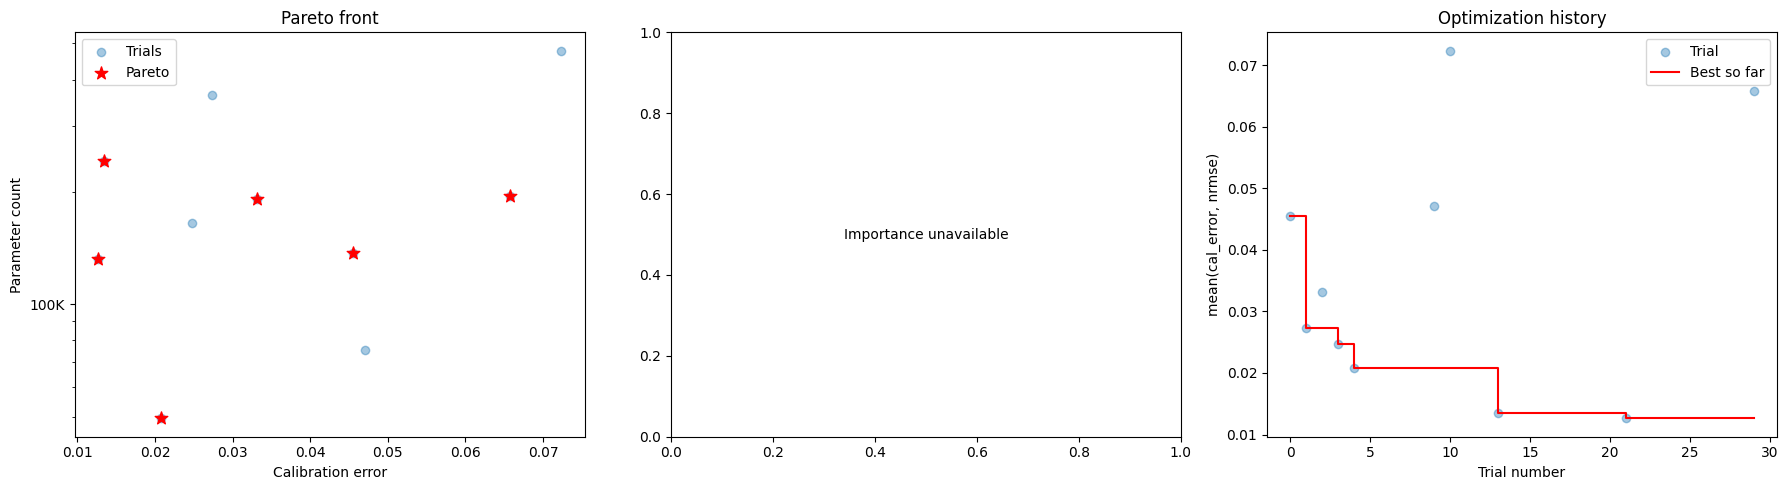

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3.1 Pareto front: calibration error vs parameter count
hpo.plot_pareto_front(study, ax=axes[0])

# 3.2 Hyperparameter importance (fANOVA)
hpo.plot_param_importance(study, ax=axes[1])

# 3.3 Optimization history: mean(cal_error, nrmse) over trials
trained = [
    t for t in study.trials
    if t.values is not None and "rejected_reason" not in t.user_attrs
]
if trained:
    trained.sort(key=lambda t: t.number)
    trial_nums = [t.number for t in trained]
    # values[0] = mean(calibration_error, nrmse) in "mean" mode
    obj_values = [t.values[0] for t in trained]
    best_so_far = [min(obj_values[: i + 1]) for i in range(len(obj_values))]
    axes[2].scatter(trial_nums, obj_values, alpha=0.4, label="Trial")
    axes[2].step(trial_nums, best_so_far, where="post", color="red", label="Best so far")
    axes[2].set_xlabel("Trial number")
    axes[2].set_ylabel("mean(cal_error, nrmse)")
    axes[2].set_title("Optimization history")
    axes[2].legend()

plt.tight_layout()
plt.show()

### 3.4 Tabular Summary

`trials_to_dataframe` converts completed trials into a `pandas.DataFrame` with one row per trial and columns for every hyperparameter, both objective values, and validation metrics (NRMSE, correlation, coverage, etc.). Budget-rejected trials are excluded by default.

The table is sorted by calibration error (the first objective) so the best architectures appear at the top.

In [5]:
df = hpo.trials_to_dataframe(study)
print(f"Completed trials: {len(df)}")

# Show the most informative columns, sorted by calibration error
key_cols = ["trial_number", "calibration_error", "param_count", "nrmse", "correlation",
            "coverage_90", "coverage_95", "training_time_s"]
display_cols = [c for c in key_cols if c in df.columns]
df.sort_values("calibration_error")[display_cols].head(10)

Completed trials: 10


,trial_number,calibration_error,param_count,nrmse,correlation,coverage_90,coverage_95,training_time_s
8,21,0.012632,132514,0.055671,0.949069,0.91,0.97,245.14
7,13,0.013421,241486,0.048001,0.954170,0.87,0.96,220.45
4,4,0.020789,49487,0.056084,0.957441,0.94,0.96,210.83
3,3,0.024737,165028,0.057905,0.937607,0.90,0.95,328.18
1,1,0.027368,363951,0.112841,0.708131,0.94,0.98,355.56
2,2,0.033158,191282,0.055013,0.947329,0.90,0.98,310.59
0,0,0.045526,137580,0.052943,0.957311,0.90,0.92,240.39
5,9,0.047105,75460,0.056800,0.946350,0.95,0.97,289.48
9,29,0.065789,194602,0.049740,0.960315,0.86,0.90,221.82
6,10,0.072368,478073,0.050488,0.949258,0.97,1.00,387.19


### 3.5 Study Summary

`summarize_study` prints a concise overview: trial counts (trained, rejected, pruned, failed), the Pareto front, the best trial by calibration error, a top-k leaderboard, and the winning hyperparameters — everything you need to decide which configuration to use for downstream inference.

In [6]:

print(hpo.summarize_study(study, top_k=5))

Study: bayesflow_hpo
Trials: 30 total | 10 trained | 12 budget-rejected | 8 pruned | 0 failed
Objectives: calibration_error, nrmse, param_count

Pareto front: 6 trials
------------------------------------------------------------
Best by calibration_error:
  Trial #21
    calibration_error        : 0.0126
    nrmse                    : 0.0557
    param_count              : 0.7116
    Param count              : 132.5K
    Training time (s)        : 245.1400
    Inference time (s)       : 32.2800
    Calibration error        : 0.0126
    NRMSE                    : 0.0557
    Correlation              : 0.9491
    Contraction              : 0.8965
    Coverage 90%             : 0.9100
    Coverage 95%             : 0.9700

Top 5 trials (by calibration_error):
------------------------------------------------------------
  #  21  |  calibration_error: 0.0126  |  nrmse: 0.0557  |  param_count: 0.7116  |  params: 132.5K  |  corr: 0.9491
  #  13  |  calibration_error: 0.0134  |  nrmse: 0.0480  |